question a

The world coordinate system is a reference coordinate system defined in the physical 3D space, independent of the camera. In our daily life, the world coordinate is the physical world projected into our eyes, though we do not have precise x,y,z mesument to define each point in world. However, in game engine like unity and unreal, there is a distnict xyz point correspodence of world coordinate in cartesian coordiate, making place the object in world coordinate system easy. 


question b 

Processing first image...
ret found


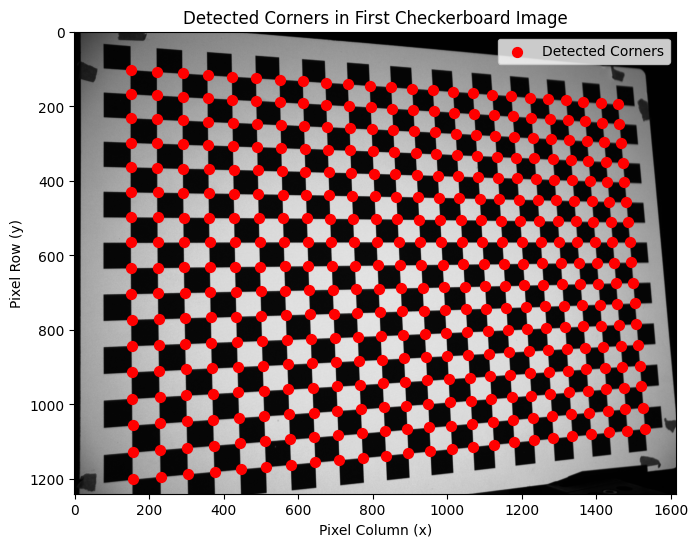

Corners successfully detected in the first image.

Processing all images...

Processing image 1: 1.png
ret found
Successfully detected 408 corners in image 1.

Processing image 2: 10.png
ret found
Successfully detected 408 corners in image 2.

Processing image 3: 11.png
ret found
Successfully detected 408 corners in image 3.

Processing image 4: 12.png
Failed to detect corners in image 4: 12.png

Processing image 5: 13.png
ret found
Successfully detected 408 corners in image 5.

Processing image 6: 14.png
ret found
Successfully detected 408 corners in image 6.

Processing image 7: 15.png
Failed to detect corners in image 7: 15.png

Processing image 8: 16.png
ret found
Successfully detected 408 corners in image 8.

Processing image 9: 17.png
ret found
Successfully detected 408 corners in image 9.

Processing image 10: 18.png
ret found
Successfully detected 408 corners in image 10.

Processing image 11: 19.png
Failed to detect corners in image 11: 19.png

Processing image 12: 2.png
ret f

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Define checkerboard size (number of inner corners per row and column)
CHECKERBOARD = (17, 24)  # Example: 9x6 inner corners

objp = np.zeros((17*24,3), np.float32)
objp[:,:2] = np.mgrid[0:17,0:24].T.reshape(-1,2)
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

# Directory containing the checkerboard images
DATA_DIR = "Data/Calibration/NoPattern"
image_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))  # Adjust extension if needed

# Function to detect and plot corners
def detect_and_plot_corners(image_path, plot_title, save_path=None):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return False, None, img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect checkerboard corners
    ret, corners=cv2.findChessboardCornersSB(gray, CHECKERBOARD, cv2.CALIB_CB_NORMALIZE_IMAGE,cv2.CALIB_CB_EXHAUSTIVE)

    if ret:
        print("ret found")
        objpoints.append(objp)
        # Refine corner positions
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001))
        imgpoints.append(corners)
        # Draw corners on image for visualization
        img_with_corners = img.copy()
        cv2.drawChessboardCorners(img_with_corners, CHECKERBOARD, corners, ret)

        # Plot corners in pixel coordinates
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        corners = corners.squeeze()  # Shape: (N, 2)
        plt.scatter(corners[:, 0], corners[:, 1], c='red', s=50, label='Detected Corners')
        plt.title(plot_title)
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        plt.legend()
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()

        return True, corners, img_with_corners
    else:
        # Plot the image even if detection failed
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"{plot_title} (No Corners Detected)")
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()
        return False, None, img

# Part a: Detect and plot corners for the first image
if image_files:
    print("Processing first image...")
    success, corners, _ = detect_and_plot_corners(
        image_files[0], 
        "Detected Corners in First Checkerboard Image"
    )
    if success:
        print("Corners successfully detected in the first image.")
    else:
        print("Failed to detect corners in the first image.")

# Part b: Detect corners in all 30 images and report failures
print("\nProcessing all images...")
failed_images = []
for i, img_path in enumerate(image_files[:30]):  # Limit to 30 images
    print(f"\nProcessing image {i+1}: {os.path.basename(img_path)}")
    save_path = f"output_image_{i+1}.png"
    success, corners, _ = detect_and_plot_corners(
        img_path, 
        f"Checkerboard Image {i+1}", 
        save_path=save_path
    )
    if not success:
        print(f"Failed to detect corners in image {i+1}: {os.path.basename(img_path)}")
        failed_images.append((i+1, img_path, save_path))
    else:
        print(f"Successfully detected {len(corners)} corners in image {i+1}.")

# Report summary
print("\nSummary:")
print(f"Processed {min(len(image_files), 30)} images.")
print(f"Number of images with failed corner detection: {len(failed_images)}")
if failed_images:
    print("Images with failed corner detection:")
    for idx, img_path, save_path in failed_images:
        print(f"Image {idx}: {os.path.basename(img_path)} (see {save_path})")
else:
    print("All corners successfully detected in all images.")

# Potential reasons for corner detection failures
if failed_images:
    print("\nPossible reasons for corner detection failures:")
    print("- Checkerboard pattern size mismatch: The specified pattern (9x6) may not match the actual checkerboard.")
    print("- Poor image quality: Low contrast, blur, or noise may prevent accurate corner detection.")
    print("- Occlusion or partial visibility: The checkerboard may be partially obscured or out of the frame.")
    print("- Incorrect flags or parameters: The detection flags may not be suitable for the image conditions.")
    print("- Lighting issues: Uneven lighting or reflections may interfere with corner detection.")
    print("- Image format or loading issues: Corrupted or improperly loaded images may cause failures.")

No all 30 can be sucessfully detected, 

When Processed 30 images.
Number of images with failed corner detection: 11
Images with failed corner detection:
Image 4: 12.png (see output_image_4.png)
Image 7: 15.png (see output_image_7.png)
Image 11: 19.png (see output_image_11.png)
Image 17: 24.png (see output_image_17.png)
Image 18: 25.png (see output_image_18.png)
Image 19: 26.png (see output_image_19.png)
Image 20: 27.png (see output_image_20.png)
Image 22: 29.png (see output_image_22.png)
Image 23: 3.png (see output_image_23.png)
Image 27: 6.png (see output_image_27.png)
Image 30: 9.png (see output_image_30.png)


Possible reasons for corner detection failures:
- Checkerboard pattern size mismatch: The specified pattern (9x6) may not match the actual checkerboard.
- Poor image quality: Low contrast, blur, or noise may prevent accurate corner detection.
- Occlusion or partial visibility: The checkerboard may be partially obscured or out of the frame.
- Incorrect flags or parameters: The detection flags may not be suitable for the image conditions.
- Lighting issues: Uneven lighting or reflections may interfere with corner detection.
- Image format or loading issues: Corrupted or improperly loaded images may cause failures.

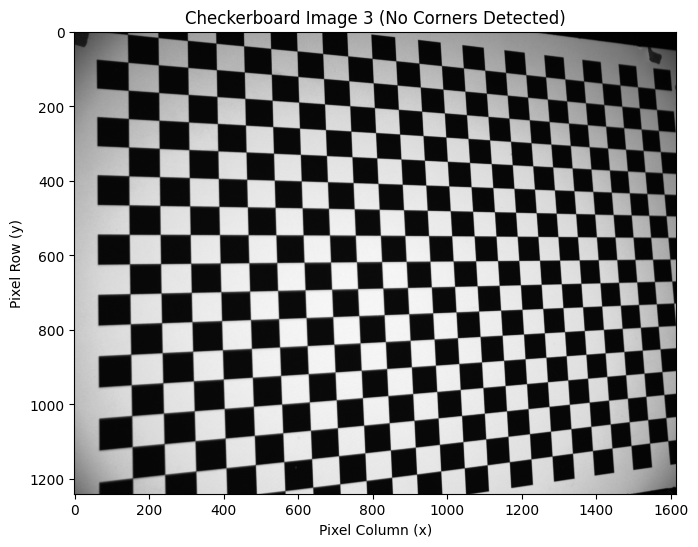

In [27]:
# 4.png
# Occlusion or partial visibility: The checkerboard lower left part may be partially obscured or out of the frame.
success, corners, _ = detect_and_plot_corners(
        "Data/Calibration/NoPattern/3.png", 
        f"Checkerboard Image {3}"
    )

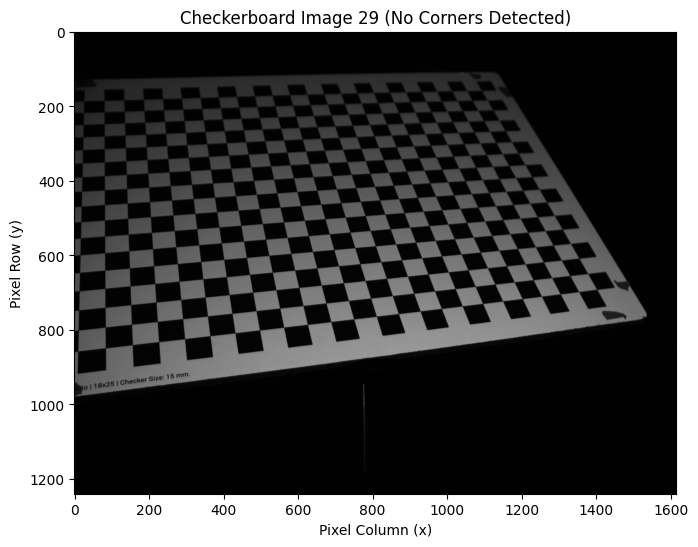

In [28]:
# 29.png
# - Lighting issues: Uneven lighting or reflections may interfere with corner detection.
# Poor image quality: Low contrast, blur, or noise may prevent accurate corner detection.
success, corners, _ = detect_and_plot_corners(
        "Data/Calibration/NoPattern/29.png", 
        f"Checkerboard Image {29}"
    )

Question c

In [30]:
img = cv2.imread("Data/Calibration/NoPattern/29.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
camera_width=img.shape[0]
camera_height=img.shape[1]
Number_of_Images=19
criteriaEnd = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001)  # Termination criteria for estimateCameraParams
reprojectionError1, camera_matrix1, dist_coeffs1, rotation_vectors, translation_vectors = cv2.calibrateCamera(
    objpoints, imgpoints, (camera_width, camera_height), None, None,
    flags=cv2.CALIB_FIX_K4 + cv2.CALIB_FIX_K5 + cv2.CALIB_FIX_K6,criteria=criteriaEnd
)
print(reprojectionError1)

0.11301917717200992


question d

[[240. 345.   0.]
 [225. 345.   0.]
 [210. 345.   0.]
 ...
 [ 30.   0.   0.]
 [ 15.   0.   0.]
 [  0.   0.   0.]]


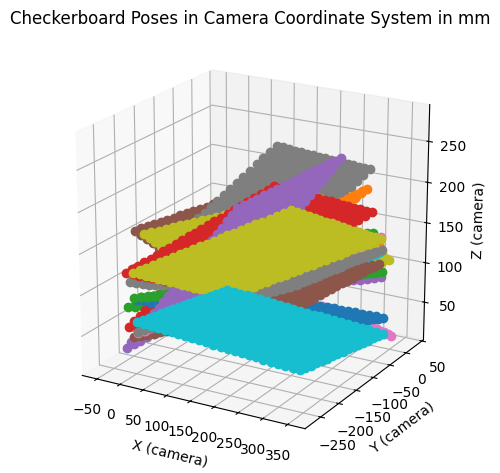

In [33]:
def generate_checkerboard_points(board_size, square_size):
    objp = np.zeros((board_size[0] * board_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:board_size[0], 0:board_size[1]].T.reshape(-1, 2)
    objnew=objp[::-1]
    return objnew * square_size

def showExtrinsics(Checker_Points, rvecs, tvecs):
    """
    Visualizes all checkerboard poses in 3D using the extrinsic parameters
    returned from cv2.calibrateCamera.

    Parameters:
    - Checker_Points: np.ndarray of shape (N, 3), 3D checkerboard points in object coordinates
    - rvecs: list of rotation vectors (from calibrateCamera), one per view
    - tvecs: list of translation vectors (from calibrateCamera), one per view
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for rvec, tvec in zip(rvecs, tvecs):
        # Convert rotation vector to rotation matrix
        R, _ = cv2.Rodrigues(rvec)
        T = np.asarray(tvec).reshape(3, 1)

        # Transform the object points to the camera coordinate system
        transformed_points = (R @ Checker_Points.T + T).T  # shape (N, 3)

        # Plot the transformed checkerboard
        ax.plot(transformed_points[:, 0], transformed_points[:, 1], transformed_points[:, 2], 'o-')

    ax.set_xlabel('X (camera)')
    ax.set_ylabel('Y (camera)')
    ax.set_zlabel('Z (camera)')
    ax.set_title('Checkerboard Poses in Camera Coordinate System in mm')
    ax.view_init(elev=20, azim=-60)
    ax.set_box_aspect([1,1,1])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

squareSize = 15 # 15 mm
worldPoints = generate_checkerboard_points(CHECKERBOARD, squareSize)  #Set up general checkerboard points in 3D object space

print(worldPoints)
showExtrinsics(worldPoints, rotation_vectors, translation_vectors)